In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

%load_ext autoreload
%autoreload 2

import os
os.chdir(os.path.expanduser("/workspaces/capstone_imperial_ml_ai/src"))

from ml.data import DataLoader, TransformUtils
from ml.plot import PlotUtils

In [41]:
X, y = DataLoader.load_data(function_name="function_1")

Loaded data from /workspaces/capstone_imperial_ml_ai/data/initial_data/function_1
Input shape: (10, 2), Output shape: (10,)


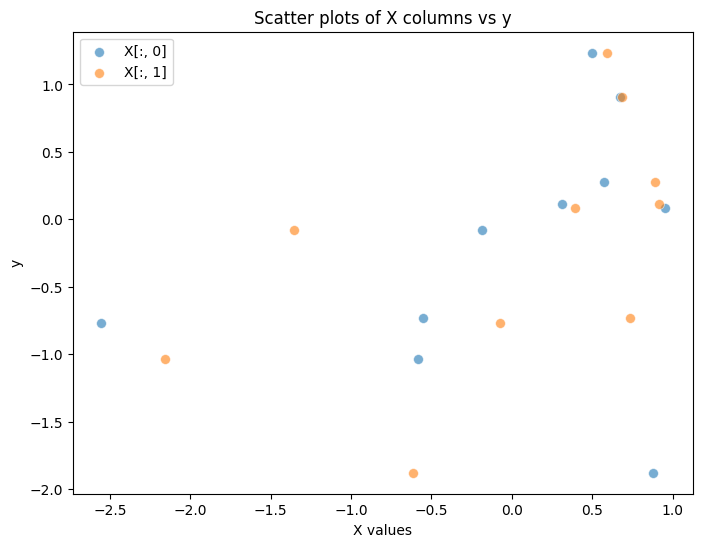

In [38]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import make_pipeline

x_scaler = StandardScaler(with_mean=True, with_std=True)
y_scaler = RobustScaler()

x_log = np.log(np.abs(X))
y_log = np.log(np.abs(y)).reshape(-1, 1)

X_transformed = x_scaler.fit_transform(x_log)
y_transformed = y_scaler.fit_transform(y_log).ravel()

PlotUtils.scatter(X_transformed, y_transformed)

In [39]:

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

# 1. Matern(nu=2.5): The 5/2 kernel we discussed.
# 2. WhiteKernel: This handles "Noise". It tells the model 
#    "The data isn't perfect, allow for some wiggle room."
kernel = Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 2e2), nu=2.5) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-5, 1e1))

model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=100, normalize_y=True)

model.fit(X_transformed, y_transformed)


print("Model Trained.")
print(f"Learned Kernel Parameters: {model.kernel_}")


/workspaces/capstone_imperial_ml_ai/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,kernel,Matern(length...e_level=1e-05)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,100
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,"Matern(length...1, 1], nu=2.5)"
,kernel__k2,WhiteKernel(noise_level=1e-05)
,kernel__k1__length_scale,"[1.0, 1.0]"


Model Trained.
Learned Kernel Parameters: Matern(length_scale=[0.625, 0.368], nu=2.5) + WhiteKernel(noise_level=1e-05)


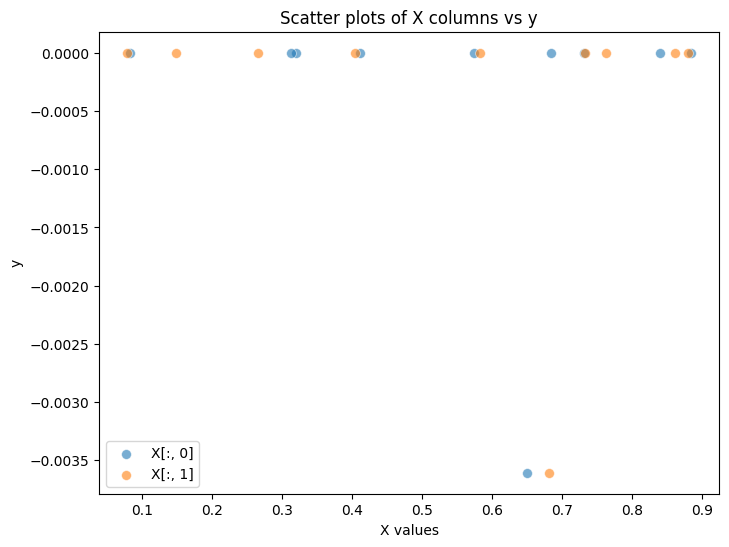

In [42]:
PlotUtils.scatter(X, y)

In [47]:
def predict(X_new):
    X_new_log = np.log(np.abs(X_new))
    X_new_transformed = x_scaler.transform(X_new_log)
    y_pred_transformed, y_std_transformed = model.predict(X_new_transformed, return_std=True)
    y_pred_log = y_scaler.inverse_transform(y_pred_transformed.reshape(-1, 1)).ravel()
    y_pred = -1 * np.exp(y_pred_log)
    return y_pred, y_std_transformed

x_space = np.linspace(0.6, 0.70, 10)
x_space = np.array([[x1, x1] for x1 in x_space])
y_pred, y_std = predict(x_space)
print("Predictions:")
for xi, yi, si in zip(x_space, y_pred, y_std):
    print(f"X: {xi}, Predicted y: {yi}, Std Dev: {si}")

Predictions:
X: [0.6 0.6], Predicted y: -2.9522863921652e-12, Std Dev: 0.3734322930036518
X: [0.61111111 0.61111111], Predicted y: -1.4486299100647883e-09, Std Dev: 0.3136562374327527
X: [0.62222222 0.62222222], Predicted y: -2.661215382469974e-07, Std Dev: 0.25422944911919015
X: [0.63333333 0.63333333], Predicted y: -1.5087440858306968e-05, Std Dev: 0.19729962276737054
X: [0.64444444 0.64444444], Predicted y: -0.00022258575543855153, Std Dev: 0.14578492384389932
X: [0.65555556 0.65555556], Predicted y: -0.0007499074382472938, Std Dev: 0.10383321245936625
X: [0.66666667 0.66666667], Predicted y: -0.0005383276464584535, Std Dev: 0.07683922780561867
X: [0.67777778 0.67777778], Predicted y: -8.367047332097529e-05, Std Dev: 0.06685642062586386
X: [0.68888889 0.68888889], Predicted y: -3.161184902315106e-06, Std Dev: 0.06535639900068314
X: [0.7 0.7], Predicted y: -3.53587371633314e-08, Std Dev: 0.06107092853352085
